# Content Based

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from IPython.utils.openpy import source_to_unicode
from pandas import read_csv

In [4]:
print(os.getcwd())

/Users/semikzr/PycharmProjects/movie-recommender-system/notebooks


In [5]:
df = pd.read_csv('../data/movie.csv')
df.head()
df_rating = pd.read_csv('../data/rating.csv')

In [6]:
df.columns

Index(['movieId', 'title', 'genres'], dtype='str')

In [7]:
df.genres.value_counts()

genres
Drama                                        4520
Comedy                                       2294
Documentary                                  1942
Comedy|Drama                                 1264
Drama|Romance                                1075
                                             ... 
Adventure|Children|Drama|Sci-Fi                 1
Children|Documentary|Drama                      1
Action|Adventure|Animation|Fantasy|Horror       1
Animation|Children|Comedy|Fantasy|Sci-Fi        1
Animation|Children|Comedy|Western               1
Name: count, Length: 1342, dtype: int64

In [8]:
df_rating.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

In [9]:
df_rating.rating.value_counts()

rating
4.0    5561926
3.0    4291193
5.0    2898660
3.5    2200156
4.5    1534824
2.0    1430997
2.5     883398
1.0     680732
1.5     279252
0.5     239125
Name: count, dtype: int64

In [10]:
avg_rating = df_rating.groupby('movieId')['rating'].mean().reset_index()


In [11]:
avg_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  26744 non-null  int64  
 1   rating   26744 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 418.0 KB


In [12]:
merged_df = pd.merge(df, df_rating, on='movieId')
merged_df.head()
avg_merged_df = pd.merge(df , avg_rating, on='movieId')

In [13]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   movieId    int64  
 1   title      str    
 2   genres     str    
 3   userId     int64  
 4   rating     float64
 5   timestamp  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 915.5 MB


In [14]:
avg_merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  26744 non-null  int64  
 1   title    26744 non-null  str    
 2   genres   26744 non-null  str    
 3   rating   26744 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 835.9 KB


### GENRE SCORES ###

In [15]:
genre_df = avg_merged_df.copy()

genre_df['genres'] = genre_df['genres'].apply(lambda x: x.split('|')) # split the genres into a list

genre_df = genre_df.explode("genres")

genre_scores = genre_df.groupby('genres')['rating'].mean().sort_values(ascending=False)

# sort the genres by average rating


In [16]:
genre_count = genre_df["genres"].value_counts()
print(genre_count)

genres
Drama                 13062
Comedy                 8232
Thriller               4129
Romance                4029
Action                 3466
Crime                  2889
Horror                 2590
Documentary            2391
Adventure              2287
Sci-Fi                 1720
Mystery                1489
Fantasy                1398
War                    1173
Children               1118
Musical                1016
Animation              1015
Western                 656
Film-Noir               322
(no genres listed)      242
IMAX                    195
Name: count, dtype: int64


<Axes: title={'center': 'Average Rating by Genre'}, ylabel='genres'>

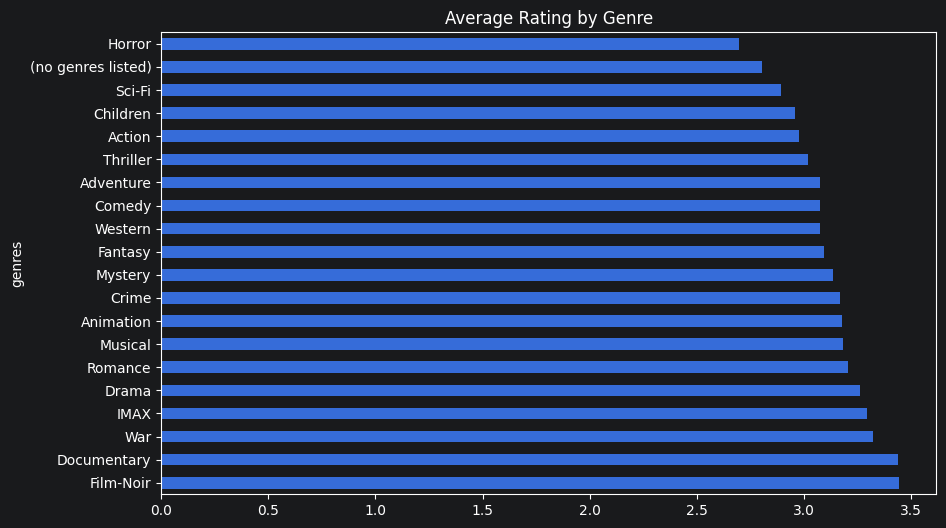

In [17]:
genre_scores.plot(kind="barh", figsize=(10,6), title="Average Rating by Genre")

<Axes: title={'center': 'Average Rating by Genre'}, xlabel='rating', ylabel='genres'>

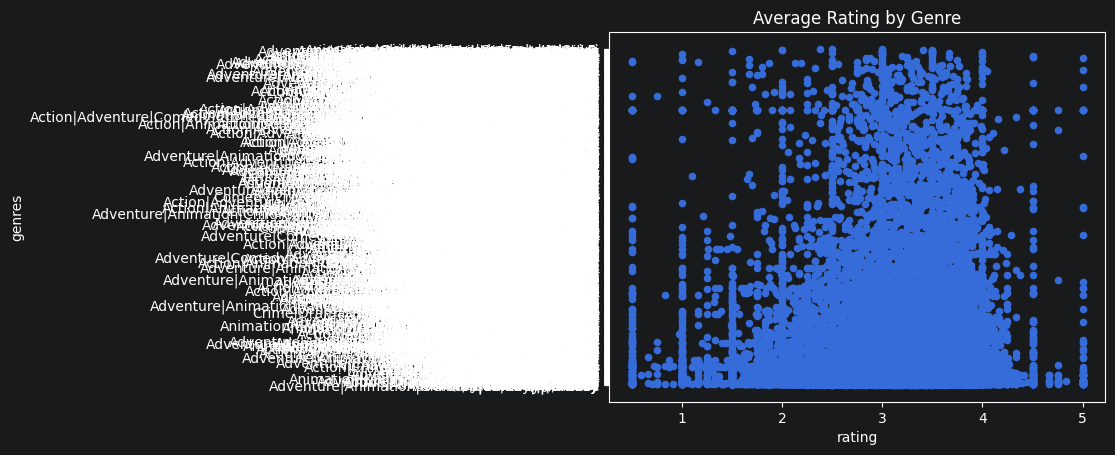

In [18]:
avg_merged_df.plot(kind="scatter", x="rating", y="genres", title="Average Rating by Genre")

 # Notes
  - Create new df for find rating count for all movie
  - Save the filtered movie feature data frame as csv file to data/processed

In [19]:
avg_merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  26744 non-null  int64  
 1   title    26744 non-null  str    
 2   genres   26744 non-null  str    
 3   rating   26744 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 835.9 KB


In [20]:
count_df = df_rating.groupby("movieId").size().reset_index(name="rating_count")
count_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   movieId       26744 non-null  int64
 1   rating_count  26744 non-null  int64
dtypes: int64(2)
memory usage: 418.0 KB


In [21]:
popularity_df = avg_merged_df.merge(count_df,on="movieId")
popularity_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movieId       26744 non-null  int64  
 1   title         26744 non-null  str    
 2   genres        26744 non-null  str    
 3   rating        26744 non-null  float64
 4   rating_count  26744 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 1.0 MB


In [22]:
filtered_popularity_df = popularity_df[popularity_df['rating_count'] >= 60]

In [23]:
filtered_popularity_df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 0 to 25693
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movieId       10000 non-null  int64  
 1   title         10000 non-null  str    
 2   genres        10000 non-null  str    
 3   rating        10000 non-null  float64
 4   rating_count  10000 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 468.8 KB


<Axes: title={'center': 'Rating vs Rating Count'}, xlabel='rating', ylabel='rating_count'>

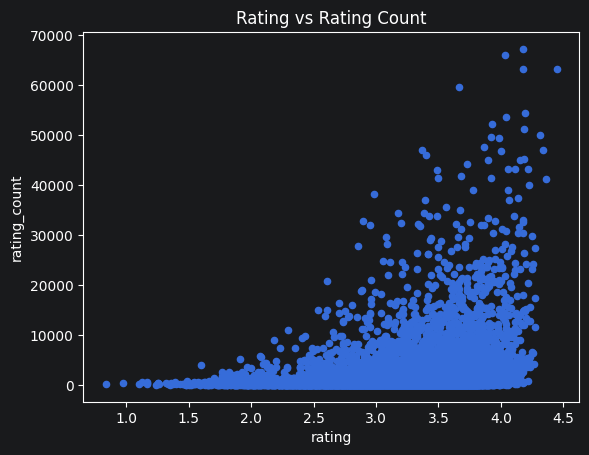

In [24]:
filtered_popularity_df.plot(kind="scatter", x="rating", y="rating_count", title="Rating vs Rating Count")

<Axes: title={'center': 'Rating vs Rating Count'}, xlabel='rating', ylabel='rating_count'>

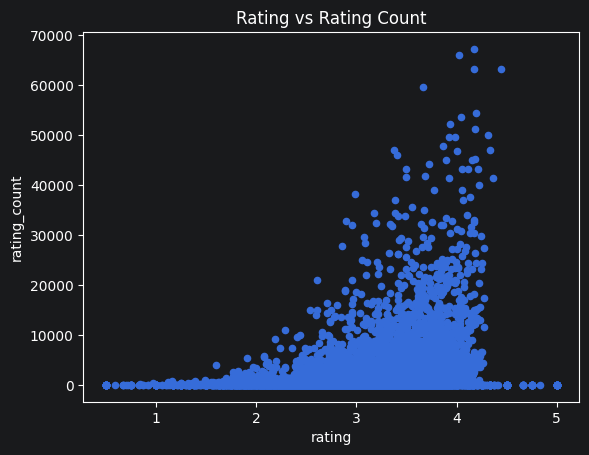

In [25]:
popularity_df.plot(kind="scatter", x="rating", y="rating_count", title="Rating vs Rating Count")

In [26]:
filtered_popularity_df.to_csv("../data/processed/movie_features.csv", index=False)

# Collabrative Fitering

In [27]:
df_rating.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  str    
dtypes: float64(1), int64(2), str(1)
memory usage: 610.4 MB


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 639.5 KB


In [29]:
# Her kullanıcının verdiği oy sayısı
user_rating_count = df_rating.groupby("userId").size()

user_rating_count.head()

userId
1    175
2     61
3    187
4     28
5     66
dtype: int64

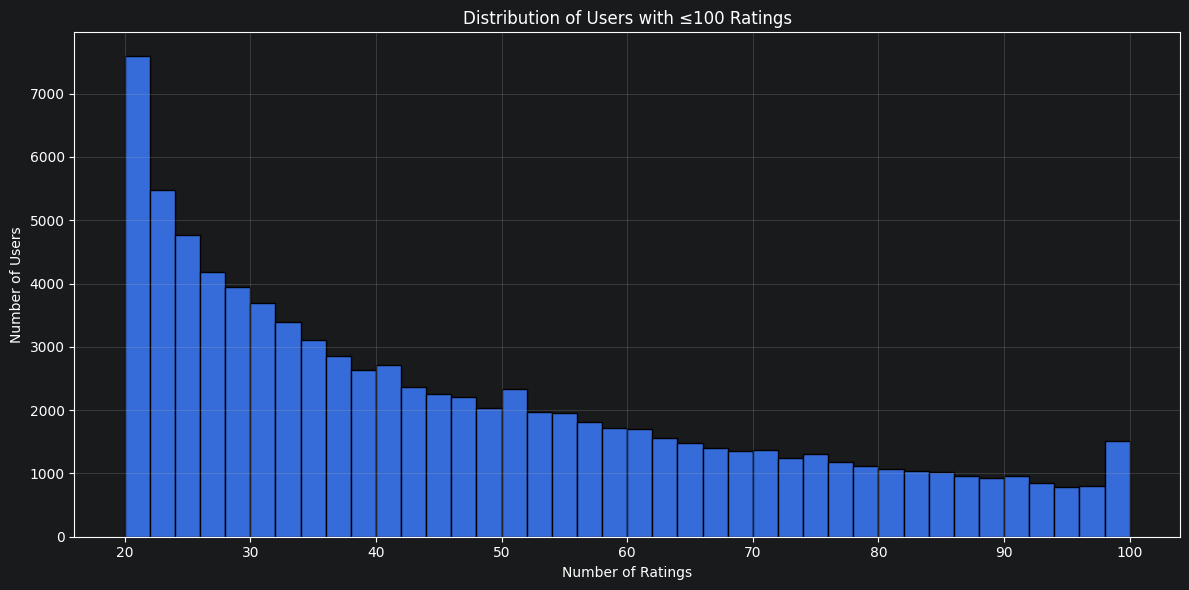

In [51]:
# Just to see the distribution of users with less than 100 ratings
low_activity_users = user_rating_count[user_rating_count <= 100]

plt.figure(figsize=(12,6))

plt.hist(low_activity_users, bins=40, edgecolor="black")

plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.title("Distribution of Users with ≤100 Ratings")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
inactive_users = user_rating_count[user_rating_count <= 30]
inactive_users.info()

<class 'pandas.Series'>
Index: 27878 entries, 4 to 138491
Series name: None
Non-Null Count  Dtype
--------------  -----
27878 non-null  int64
dtypes: int64(1)
memory usage: 435.6 KB


In [57]:
user_rating_count.info()

<class 'pandas.Series'>
Index: 138493 entries, 1 to 138493
Series name: None
Non-Null Count   Dtype
--------------   -----
138493 non-null  int64
dtypes: int64(1)
memory usage: 2.1 MB


In [65]:
# Inactive Users
inactive_users = user_rating_count[user_rating_count <= 30].index

# Filter out inactive users from the rating data
df_rating_filtered = df_rating[
    ~df_rating["userId"].isin(inactive_users)
]

print("Eski veri boyutu :", df_rating.shape)
print("Yeni veri boyutu :", df_rating_filtered.shape)

Eski veri boyutu : (20000263, 4)
Yeni veri boyutu : (19324695, 4)


In [70]:
user_mean = df_rating_filtered.groupby("userId")["rating"].mean()

In [71]:
df_rating_filtered["user_mean"] = df_rating_filtered["userId"].map(user_mean)

In [72]:
df_rating_filtered["normalized_rating"] = (
    df_rating_filtered["rating"] -
    df_rating_filtered["user_mean"]
)

In [73]:
df_rating_filtered.info()

<class 'pandas.DataFrame'>
Index: 19324695 entries, 0 to 20000262
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   userId             int64  
 1   movieId            int64  
 2   rating             float64
 3   timestamp          str    
 4   user_mean          float64
 5   normalized_rating  float64
dtypes: float64(3), int64(2), str(1)
memory usage: 1.0 GB


In [74]:
check = df_rating_filtered.groupby("userId")["normalized_rating"].mean()

print(check.describe())

count    1.106150e+05
mean     1.114048e-18
std      1.574271e-16
min     -4.434952e-16
25%     -1.181522e-16
50%      0.000000e+00
75%      1.211152e-16
max      4.432744e-16
Name: normalized_rating, dtype: float64


In [75]:
user = 100

df_rating_filtered[df_rating_filtered["userId"] == user][

    ["movieId", "rating", "user_mean", "normalized_rating"]

].head(10)

,movieId,rating,user_mean,normalized_rating
11049,14,3.0,3.5,-0.5
11050,25,4.0,3.5,0.5
11051,32,3.0,3.5,-0.5
11052,39,3.0,3.5,-0.5
11053,50,5.0,3.5,1.5
11054,70,3.0,3.5,-0.5
11055,161,3.0,3.5,-0.5
11056,162,4.0,3.5,0.5
11057,185,2.0,3.5,-1.5
11058,194,3.0,3.5,-0.5


User bias was reduced by mean-centering the ratings. Each user’s average rating was subtracted from all of their ratings. The normalization was verified by computing the mean of the normalized ratings for each user, which resulted in values numerically equal to zero (mean ≈ 1.11 × 10⁻¹⁸), confirming that the normalization was successfully applied.

In [76]:
df_rating_filtered.info()

<class 'pandas.DataFrame'>
Index: 19324695 entries, 0 to 20000262
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   userId             int64  
 1   movieId            int64  
 2   rating             float64
 3   timestamp          str    
 4   user_mean          float64
 5   normalized_rating  float64
dtypes: float64(3), int64(2), str(1)
memory usage: 1.0 GB


In [78]:
cf_df = df_rating_filtered[
    ["userId", "movieId", "normalized_rating"]
].copy()


In [79]:
cf_df.info()

<class 'pandas.DataFrame'>
Index: 19324695 entries, 0 to 20000262
Data columns (total 3 columns):
 #   Column             Dtype  
---  ------             -----  
 0   userId             int64  
 1   movieId            int64  
 2   normalized_rating  float64
dtypes: float64(1), int64(2)
memory usage: 589.7 MB


In [85]:
cf_df["userId"] = cf_df["userId"].astype("int32")
cf_df["movieId"] = cf_df["movieId"].astype("int32")
cf_df["normalized_rating"] = cf_df["normalized_rating"].astype("float32")

cf_df.info()

<class 'pandas.DataFrame'>
Index: 19324695 entries, 0 to 20000262
Data columns (total 3 columns):
 #   Column             Dtype  
---  ------             -----  
 0   userId             int32  
 1   movieId            int32  
 2   normalized_rating  float32
dtypes: float32(1), int32(2)
memory usage: 368.6 MB


In [86]:
cf_df.to_csv(
    "../data/processed/collabrative_features.csv",
    index=False
)